# Spectral Co-Adding

Name: Wesley Stevick

Date: Nov 14

### Peak Finding
1. Use the best peak-finding tools from class to find the same 5 most prominent peaks in every channel within one data file (this may involve finding more than 5 peaks and figuring out an algorithm to find which peaks should map to which.)
2. Fit these peaks with a Gaussian on top of a linear background.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from functions import my_peaks, normal_binify, to_coords

sns.set(context="notebook", style="whitegrid")

In [2]:
import h5py

channels = pd.Series()

with h5py.File("Gamma/210601_NBS295-106/20210601_152616_mass-001.hdf5") as f:
    for key in f.keys():
        channels[int(key.removeprefix("chan"))] = np.array(f[key]["filt_value"])

channels.sort_index(inplace=True)

In [3]:
# trim impossible negative energies, and noise in the last percentile
for k in channels.index:
    channels[k] = channels[k][channels[k] > 0]
    channels[k] = channels[k][channels[k] < np.percentile(channels[k], 99)]

In [5]:
channel_data = pd.read_pickle("channel_data.pickle")

In [ ]:
channel_data = pd.DataFrame(
    {
        "values": channels,
        "median": [np.median(values[values > 0]) for values in channels],
        "count": [len(values[values > 0]) for values in channels],
    }
)
ax = channel_data.plot.scatter(x="median", y="count")
ax.figure.tight_layout()
# ax.figure.savefig('scatter-unfiltered.png')

In [ ]:
median_sort = channel_data["median"].sort_values().index
count_sort = channel_data["count"].sort_values().index
fig, axes = plt.subplots(nrows=6, ncols=3)
fig.set_size_inches(3 * 6, 6 * 6)
rng = np.random.default_rng()
for col, (group, name) in enumerate(
    [
        (median_sort[[0, 1, 2, -3, -2, -1]], "Extreme counts"),
        (count_sort[[0, 1, 2, -3, -2, -1]], "Extreme median"),
        (rng.choice(channel_data.index, 6, replace=False), "Random"),
    ]
):
    for row, idx in enumerate(group):
        hist, bins = normal_binify(channel_data.loc[idx]["values"], bins_to_median=1000)
        axes[row, col].step(bins, hist, where="mid")
        """
        params, _ = my_peaks(hist, bins, n=15)
        for [center, height, std, base_offset, base_slope] in params:
            axes[row, col].scatter(center, height + base_offset, color='red')
        axes[row, col].set_yscale('log')
        if row == 0:
            axes[row, col].set_title(name)
        if col == 0:
            axes[row, col].set_ylabel(['Lowest', '2nd lowest', '3rd lowest', '3rd highest', '2nd highest', 'Highest'][row])
        """
plt.tight_layout()
# fig.savefig('filtered.png')

In [3]:
channel_data = channel_data.query("(count > 50000) & (median > 4000)")
ax = channel_data.plot.scatter(x="median", y="count")
ax.figure.tight_layout()
# ax.figure.savefig('scatter-filtered.png')

NameError: name 'channel_data' is not defined

In [32]:
all_params = pd.read_csv("params.csv").set_index("channel")

In [4]:
chan1_top5 = pd.read_pickle("chan1_top5.pickle")
chan1_top5

array([[ 1.02679965e+00,  1.23222180e+01,  5.91509939e-04,
         1.32373526e+00,  1.28414109e+02],
       [ 1.03151103e+00,  1.27948434e+01,  5.53793850e-04,
         1.57191947e+00, -2.49204772e+02],
       [ 1.05180287e+00,  1.44503687e+01,  9.29288340e-04,
         1.55372223e+00, -8.50244200e+01],
       [ 7.06327385e-01,  1.54072730e+01,  5.02615712e-04,
         6.59256748e-01, -1.56113863e+01],
       [ 1.09310869e+00,  2.30875488e+01,  9.67052561e-04,
         1.84155480e+00, -5.44692903e+01]])

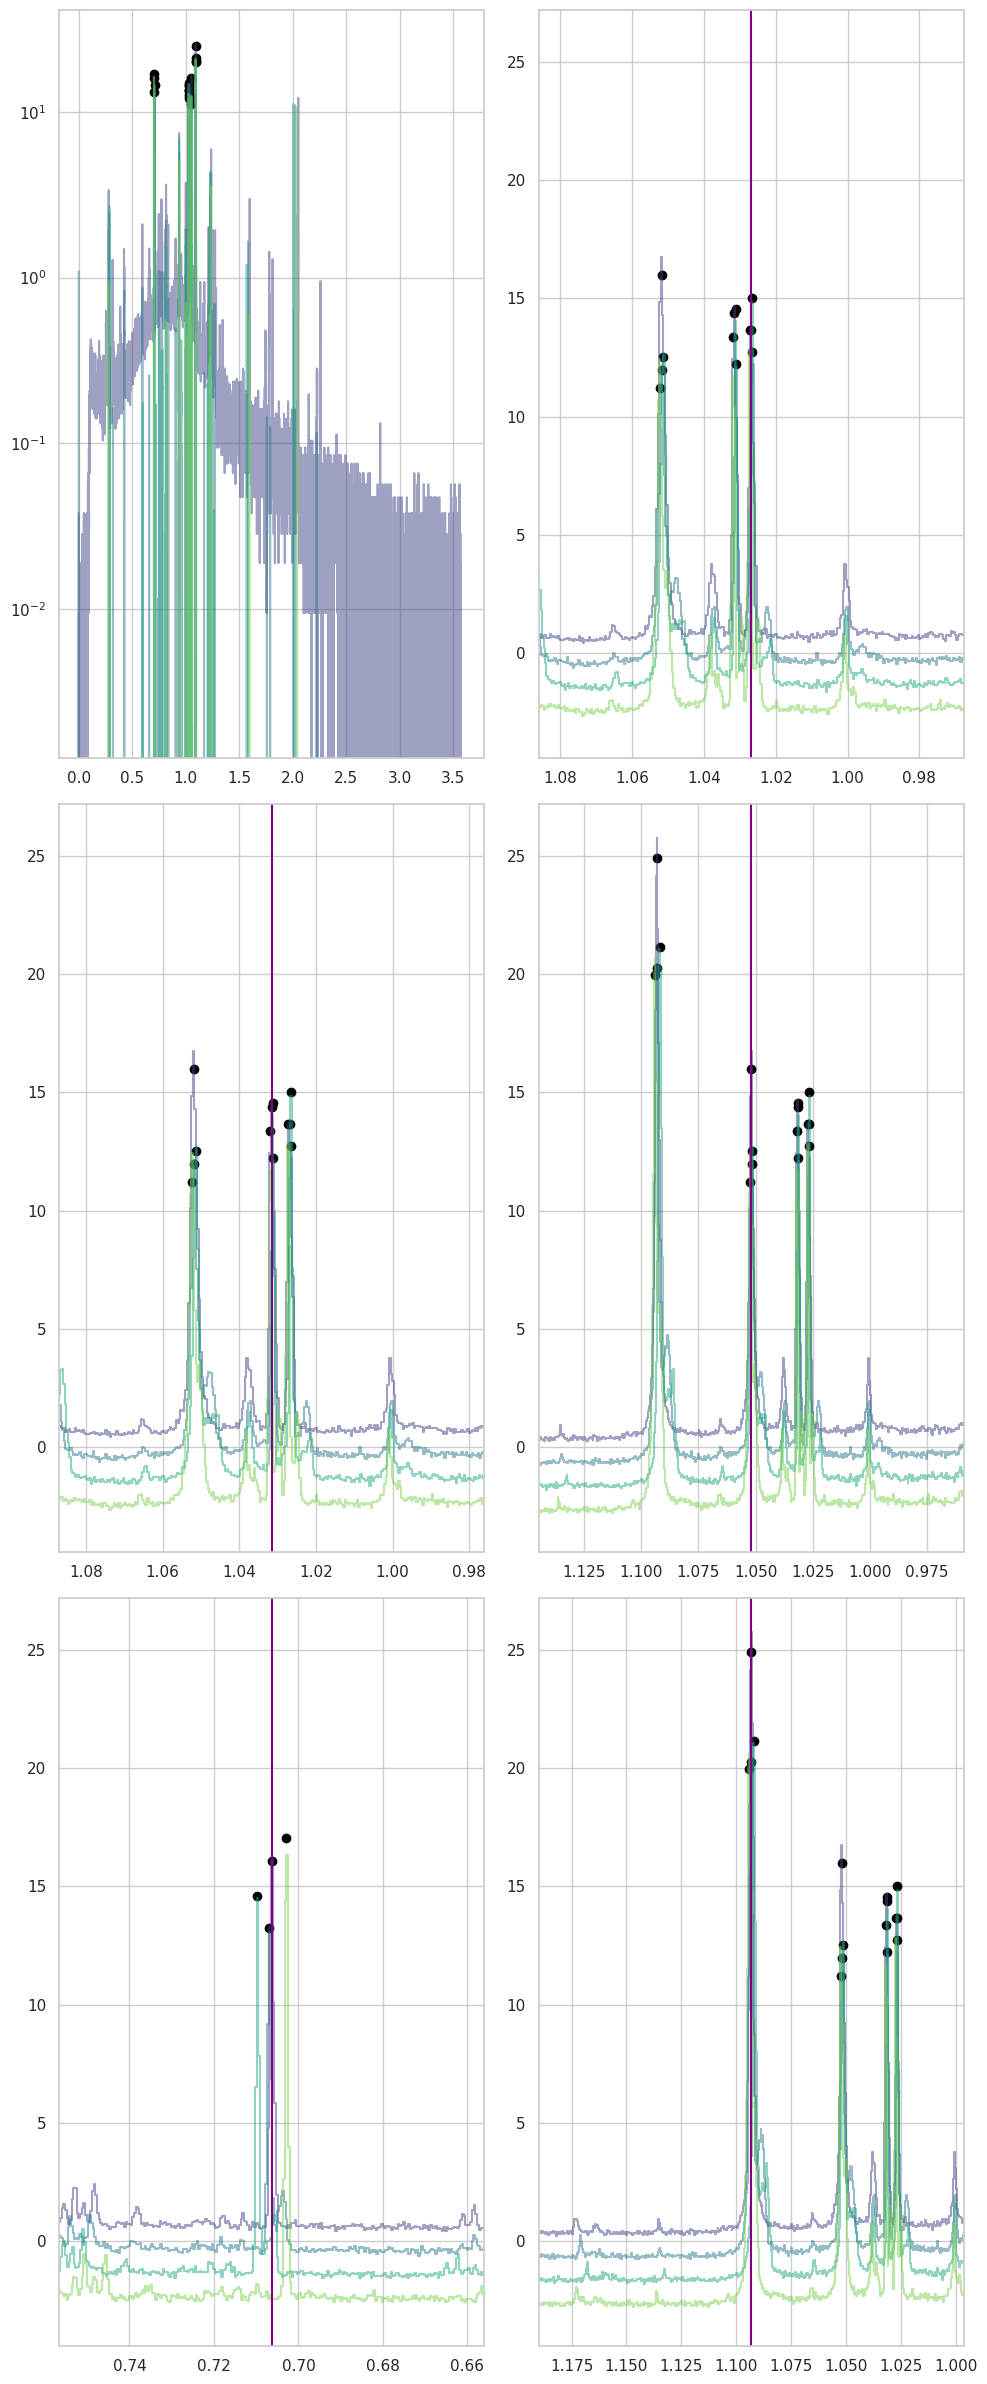

In [58]:
fig, axes = plt.subplots(nrows=3, ncols=2)
for aidx, ax in enumerate(axes.flatten()):
    a = 0

    def adjust(y):
        if i == 0:
            return y * np.exp(a)
        else:
            return y + a

    if aidx == 0:
        ax.set_yscale("log")
    for channel, stepcolor in zip(
        channel_data.index, sns.color_palette("viridis", n_colors=4)
    ):
        b = channel_data.loc[channel, "b"]
        hist, bins = normal_binify(channel_data.loc[channel, "values"])
        ax.step(bins * b, adjust(hist), color=stepcolor, alpha=0.5, where="mid")
        params = channel_data.loc[channel, "params"]
        # ax.scatter(params['center'] * b, adjust(params.eval('height + offset')), color='red', marker='.')
        matched = params.loc[channel_data.loc[channel, "matches"]]
        ax.scatter(
            matched["center"] * b,
            adjust(matched.eval("height + offset")),
            color="black",
        )
        a -= 1
for param, ax in zip(chan1_top5, axes.flatten()[1:]):
    ax.set_xlim(param[0] + param[2] * 100, param[0] - param[2] * 100)
    ax.axvline(param[0], color="purple")
fig.set_size_inches(2 * 5, 3 * 8)
plt.tight_layout()

### Traditional Analysis
3. Using splines with 5 peaks, co-add all the channels within one data file.
4. Fit the most prominent peak of each individual spectrum after scaling it. Divide the Gaussian mean by the Gaussian width ($\sigma$) and histogram this quantity (which we will refer to as the signal to noise ratio or SNR).
5. Add up all the spectra and fit the most prominent peak of the summed spectrum. Plot the SNR as a vertical dashed line on the SNR histogram from #2.
6. Repeat steps 2 and 3 for a peak that is 2 orders of magnitude smaller (i.e. 100 times less area)

### DTW Analysis
7. Use the DTW approach on all the channels within one data file to co-add them.
8. Fit the most prominent peak of each individual spectrum after scaling it. Divide the Gaussian mean by the Gaussian width ($\sigma$) and histogram this quantity (which we will refer to as the signal to noise ratio or SNR).
9. Add up all the spectra and fit the most prominent peak of the summed spectrum. Plot the SNR as a vertical dashed line on the SNR histogram from #2.
10. Repeat steps 2 and 3 for a peak that is 2 orders of magnitude smaller (i.e. 100 times less area)

## Side Quest -- DTW Optimization

Repeat steps 7-10 and optimize the various DTW options:
```
alignment_windowed = dtw(s1, s2, keep_internals=True,
                         window_type="sakoechiba", window_args={'window_size': 2})
```

## Side Quest -- Wavelets for Drift Correction

Inverse of noise reduction. We're keeping the noise, but removing the slow time constant terms!

# Parts (put here in case I want to use later, not part of code)

In [ ]:
x0 = []
windows = []
for peak in peaks:
    ([left],) = np.where(bins == peak)
    while d2y[left] < 0:
        left -= 1
    ([right],) = np.where(bins == peak)
    while d2y[right] < 0:
        right += 1
    left += int((left - right) / 2)
    right += int((right - left) / 2)
    std_guess = (bins[right] - bins[left]) / 2
    windows.append((left, right))
    baseline_slope_guess = (hist[right] - hist[left]) / 2
    baseline_offset_guess = (hist[right] + hist[left]) / 2
    [height_guess] = hist[bins == peak] - baseline_offset_guess
    x0.append(
        [peak, height_guess, std_guess, baseline_slope_guess, baseline_offset_guess]
    )

x0 = np.array(x0)
scale = x0.mean(axis=0) / 1000
x0 /= scale
x0 = x0.flatten()

In [ ]:
from scipy.stats import norm
from numba import jit


# @jit(nopython=True, parallel=True)
def normal(x, mean, std):
    return np.e ** (-((x - mean) ** 2) / (2 * std**2)) / np.sqrt(2 * np.pi * std**2)


# @jit(nopython=True)
def error(x0, hist, bins, windows):
    calculated = np.empty(shape=hist.shape, dtype="float64")
    calculated[:] = np.nan
    a = np.arange(len(bins))
    for i, (left, right) in enumerate(windows):
        window = (a >= left) & (a <= right)
        [center, height, std, base_slope, base_offset] = x0[i]
        calculated[window & np.isnan(calculated)] = 0
        peak = normal(bins[window], center, std)
        if np.isnan(height / peak.max()):
            return 6565784574721.466 * 1000000
        peak *= height / peak.max()
        calculated[window] += peak
        calculated[window] += base_slope * (bins[window] - center) + base_offset
    difference = hist - calculated
    difference = difference[~np.isnan(difference)]
    return np.sum(difference**2) + 10000 * (x0[3, :] ** 2).sum(), calculated


def make_error_function(hist, bins, windows, scale):
    return lambda x0: error(x0.reshape(-1, 5) * scale, hist, bins, windows)

In [ ]:
from scipy.optimize import minimize

minimization = minimize(ferr, x0, method="Powell")

In [ ]:
ferr = make_error_function(hist, bins, windows, scale)
err, calculated = ferr(x0)

In [ ]:
minimization

In [ ]:
x0 = minimization.x

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=2)
axes = axes.flatten()
for i in range(10):
    [center, height, std, base_slope, base_offset] = (x0.reshape(-1, 5) * scale)[i]
    std = min(std, 0.005)
    left, right = windows[i]
    a = np.arange(len(bins))
    xs = bins[(a >= left) & (a <= right)]
    axes[i].set_xlim(center - 5 * std, center + 5 * std)
    axes[i].step(bins, calculated, linewidth=10, alpha=0.5)
    axes[i].plot(xs, (xs - center) * base_slope + base_offset)
    axes[i].axvline(center)
    axes[i].errorbar(center, (height + base_offset) / 2, height / 2, linewidth=10)
    axes[i].step(bins, hist)
fig.set_size_inches(8 * 2, 6 * 5)
plt.tight_layout()

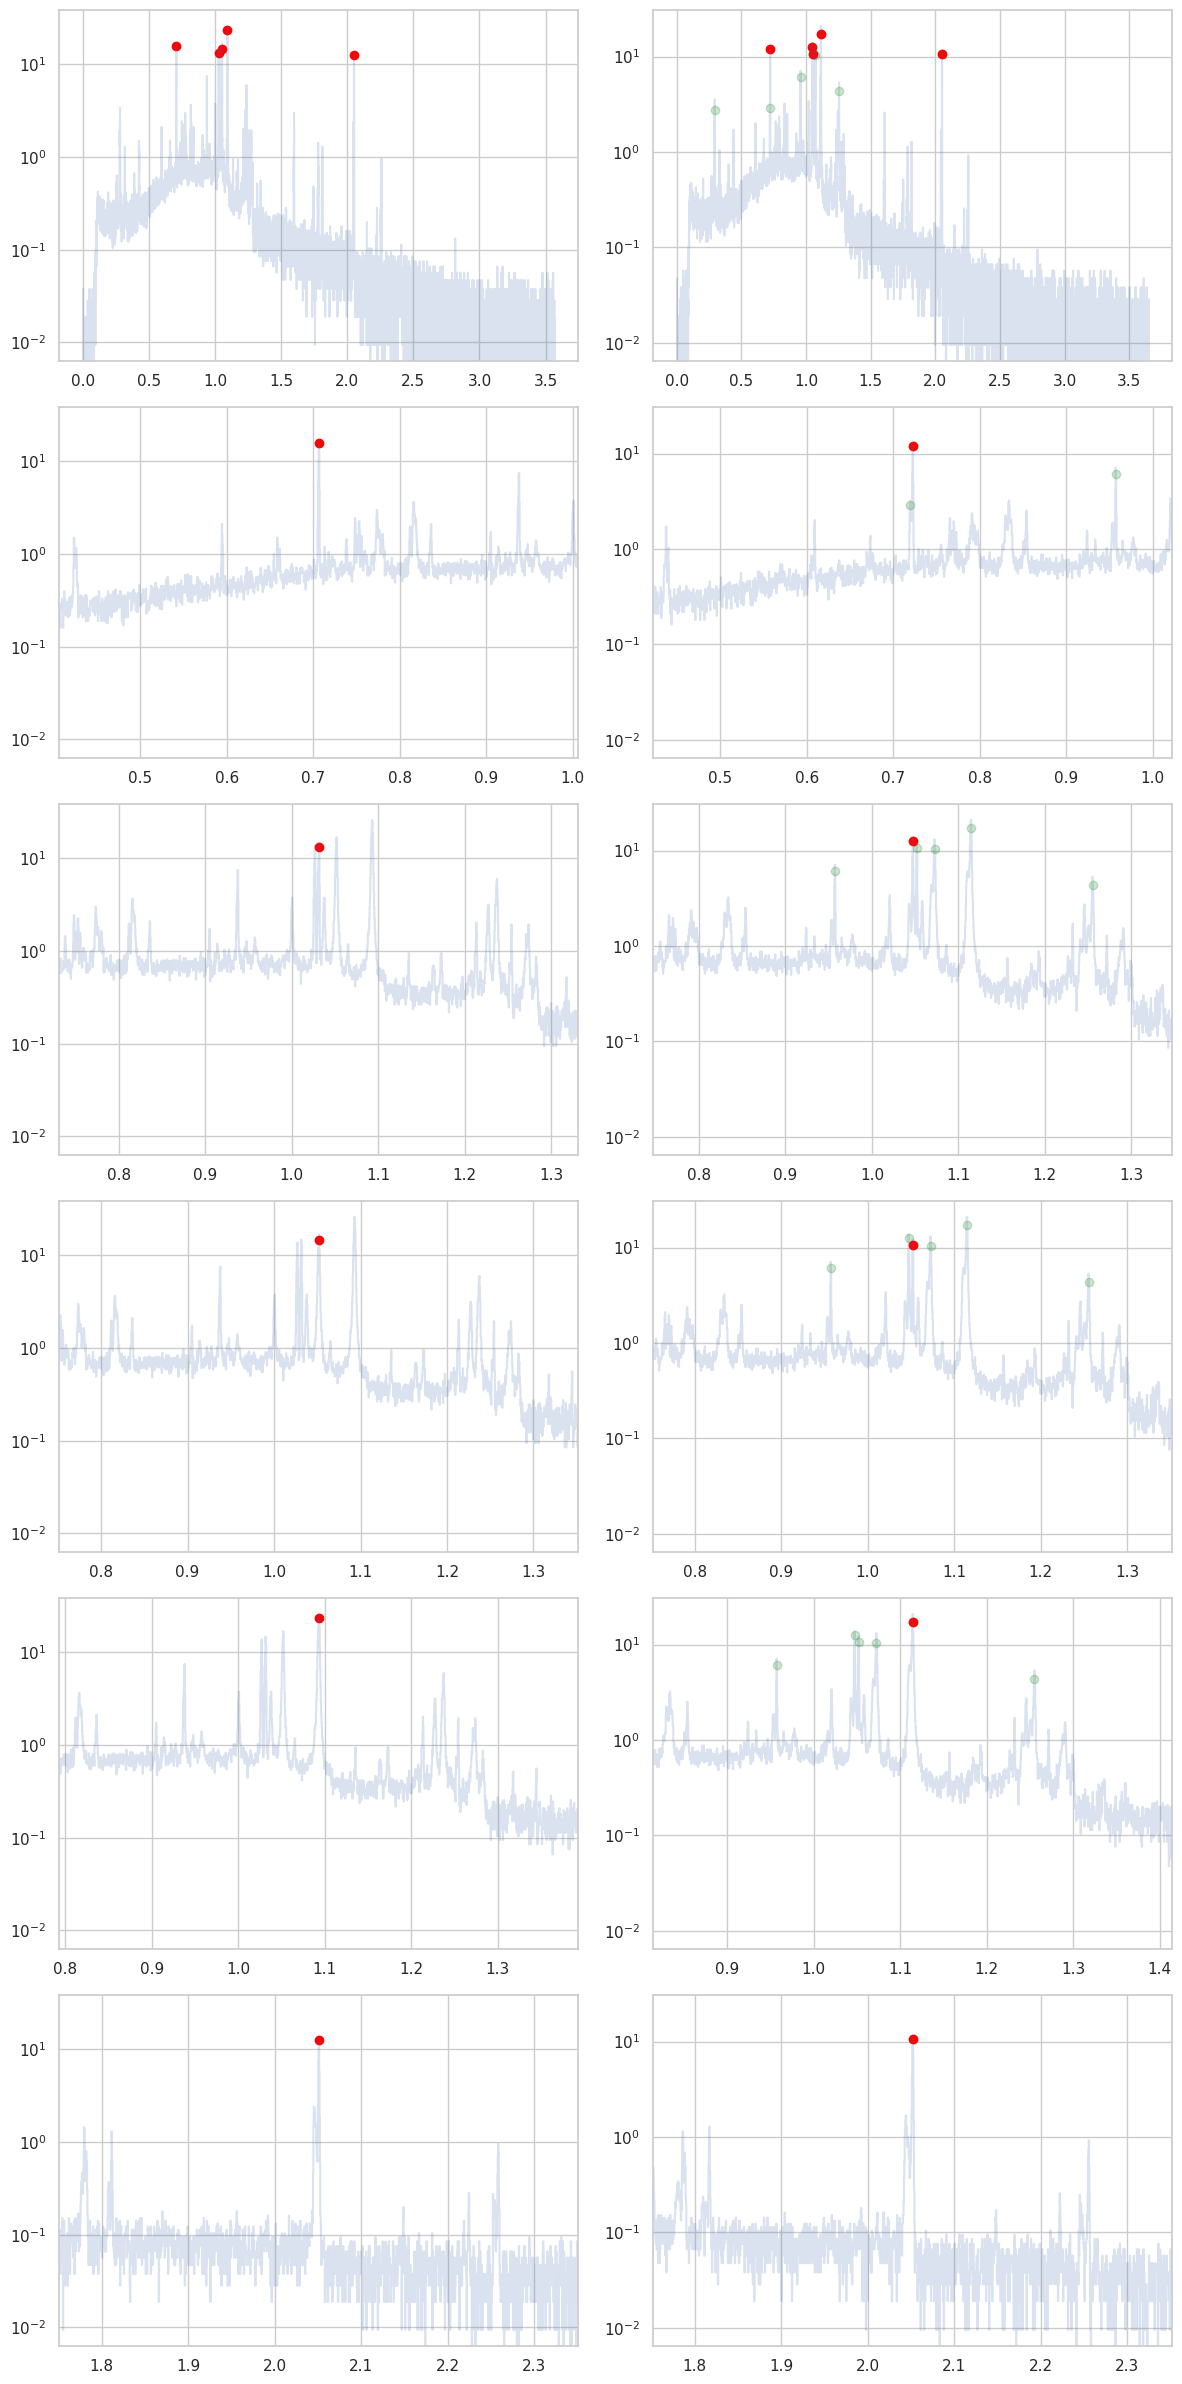

In [36]:
histr, binsr = normal_binify(channel_data.loc[19, "values"])
hist1, bins1 = normal_binify(channel_data.loc[1, "values"])
fig, axes = plt.subplots(nrows=6, ncols=2)
for col, (bins, hist, peaks) in enumerate(
    [(bins1, hist1, find_matches_of), (binsr, histr, matches[0])]
):
    for i in range(6):
        axes[i, col].step(bins, hist, where="mid", alpha=0.2)
        axes[i, col].set_yscale("log")
        if col == 1:
            axes[i, col].scatter(
                coords19[:, 0], coords19[:, 1] * 10, color="green", alpha=0.2
            )
        if i == 0:
            continue
        peak = peaks[i - 1]
        axes[0, col].scatter(peak[0], peak[1] * 10, color="red")
        axes[i, col].scatter(peak[0], peak[1] * 10, color="red")
        axes[i, col].set_xlim(peak[0] - 0.3, peak[0] + 0.3)
fig.set_size_inches(2 * 6, 6 * 4)
plt.tight_layout()

In [ ]:
values = channels[1]
hist, bins = normal_binify(values, bins_to_median=3000)
chan1_top5, windows = my_peaks(hist, bins, n=5)
fig, axes = plt.subplots(nrows=3, ncols=2)
axes = axes.flatten()
axes[0].step(bins, hist, where="mid")
axes[0].set_yscale("log")
for i, ([center, height, std, base_offset, base_slope], (left, right)) in enumerate(
    zip(chan1_top5, windows)
):
    axes[0].scatter(center, height + base_offset, color="red")
    axes[i + 1].step(bins, hist, where="mid")
    xs = np.linspace(bins[left], bins[right - 1])
    fit = linear_guass(xs, center, height, std, base_offset, base_slope)
    base = (xs - center) * base_slope + base_offset
    axes[i + 1].plot(xs, fit)
    axes[i + 1].plot(xs, base)
    axes[i + 1].set_xlim(center - 5 * std, center + 5 * std)
    axes[i + 1].axvline(center, color="red")
fig.set_size_inches(6 * 2, 4 * 3)
fig.tight_layout()
# fig.savefig('top5.png')